In [1]:
import boto3
import botocore
import functools
from IPython.core.display import display, HTML
from iterdub import iterdub as ib
from iterpop import iterpop as ip
import itertools as it
import json
import matplotlib
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
from pandas.util import hash_pandas_object
import seaborn as sns
from teeplot import teeplot as tp


In [2]:
from dishpylib.pyanalysis import calc_loglikelihoods_by_num_sets
from dishpylib.pyanalysis import count_hands_with_k_or_more_sets
from dishpylib.pyanalysis import count_hands_without_k_or_more_sets
from dishpylib.pyanalysis import estimate_interpolation_complexity
from dishpylib.pyanalysis import calc_loglikelihoods_over_set_sizes
from dishpylib.pyhelpers import get_env_context
from dishpylib.pyhelpers import get_git_revision_hash
from dishpylib.pyhelpers import make_timestamp
from dishpylib.pyhelpers import NumpyEncoder
from dishpylib.pyhelpers import preprocess_competition_fitnesses
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervmxu0kd
interpreter: 3.10.12 (main, Jan  8 2026, 06:52:19) [GCC 11.4.0]
notebook name: 2025-09-13-interspersed-nopouts
notebook path: /home/runner/work/oee4/oee4/binder/2025-09-13-interspersed-nopouts.ipynb
revision: bdac574
timestamp: 2026-01-26T16:52:01Z00:00

IPython==7.16.1
packaging==25.0


<ipython-input-3-4d790cf6450f>:1: DeprecatedWarning: print_runtime is deprecated. use nbmetalog package instead
  print_runtime()


In [4]:
teeplot_subdir = "2025-09-13-interspersed-nopouts"


In [5]:
import pandas as pd
from scipy import stats

def fit_control_t_distns(control_df):

    na_rows = control_df['Fitness Differential Focal'].isna()
    assert all( control_df[ na_rows ]['Population Extinct'] )
    print(na_rows.sum())
    control_df['Fitness Differential Focal'].fillna(0, inplace=True,)

    res = []
    for series in control_df['Competition Series'].unique():

        series_df = control_df[ control_df['Competition Series'] == series ]

        # legacy data was mixed inside of the variant_df
        # wt_vs_wt_df = series_df.groupby('Competition Repro').filter(
        #     lambda x: (x['genome variation'] == 'master').all()
        # ).groupby('Competition Repro').first().reset_index()

        # fit a t distribution to the control data
        # df is degrees of freedom
        df, loc, scale = stats.t.fit( series_df['Fitness Differential Focal'] )


        res.append({
            'Series' : series,
            'Fit Degrees of Freedom' : df,
            'Fit Loc' : loc,
            'Fit Scale' : scale,
        })

    return pd.DataFrame(res)


In [6]:
import boto3
import botocore
import functools
import pandas as pd


@functools.lru_cache
def get_control_t_distns( bucket, endeavor, stint ):

    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    control_competitions, = [*bucket_handle.objects.filter(
        Prefix=f'endeavor={endeavor}/control-competitions-focalbb-phenotypeneutral/stage=3+what=collated/stint={stint}',
    )][:1]

    control_df = pd.read_csv(
        f's3://{bucket}/{control_competitions.key}',
    )

    res = fit_control_t_distns(control_df[
        control_df["Root ID"] == 0
    ].copy())
    return res


In [7]:
import functools
from iterpop import iterpop as ip
from scipy import stats


def preprocess_competition_fitnesses(competitions_df, control_fits_df):
    # preprocess data
    @functools.lru_cache
    def h0_fit(series):
        return ip.popsingleton(
            control_fits_df[control_fits_df["Series"] == series].to_dict(
                orient="records",
            )
        )

    competitions_df["p"] = competitions_df.apply(
        lambda row: stats.t.cdf(
            row["Fitness Differential Focal"],
            h0_fit(row["genome series"])["Fit Degrees of Freedom"],
            loc=h0_fit(row["genome series"])["Fit Loc"],
            scale=h0_fit(row["genome series"])["Fit Scale"],
        ),
        axis=1,
    )
    competitions_df["Is Less Fit"] = competitions_df["p"] < 1.0 / 40
    competitions_df["Is More Fit"] = competitions_df["p"] > (1.0 -  1.0 / 40)
    competitions_df["Is Neutral"] = ~(
        competitions_df["Is Less Fit"] | competitions_df["Is More Fit"]
    )
    competitions_df["Relative Fitness"] = competitions_df.apply(
        lambda row: (
            "Significantly Advantageous"
            if row["Is More Fit"]
            else (
                "Significantly Deleterious" if row["Is Less Fit"] else "Neutral"
            )
        ),
        axis=1,
    )

    return competitions_df


# get data


In [8]:
s3_handle = boto3.resource(
    's3',
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket('prq49')

dfs = []
for stint in range(101):
    print(f'stint: {stint}')
    series_profile, = bucket_handle.objects.filter(
        Prefix=f'endeavor=16/bioticbackground-noncritical-phenotypeneutral-nopinterspersion-competitions/stage=8+what=collated/stint={stint}/',
    )

    control_fits_df = get_control_t_distns('prq49', 16, stint)
    df = pd.read_csv(
        f's3://prq49/{series_profile.key}',
    )
    df = df[df["Competition Series"] == 16005]
    df = df[df["genome morph"] != "wildtype"].copy()
    df = df[df["genome a"] == "genome"].copy()

    print(f'stint: {stint}, df length: {len(df)}')
    df["Stint"] = stint
    dfdigest = '{:x}'.format( hash_pandas_object( df ).sum() )
    print(dfdigest)
    df = preprocess_competition_fitnesses(df, control_fits_df)
    dfs.append(df)


stint: 0
0
stint: 0, df length: 48
76ca457a0f809dc4
stint: 1
0
stint: 1, df length: 72
-6cbcdf884be2a616
stint: 2
0
stint: 2, df length: 88
4f510394bb506c47
stint: 3
0
stint: 3, df length: 104
-75eb69bd6667a932
stint: 4
0
stint: 4, df length: 144
5fc4499bc5dd4fd2
stint: 5
0
stint: 5, df length: 120
bdf04bbe7ebf4e3
stint: 6
0
stint: 6, df length: 138
25195d05687ba616
stint: 7
0
stint: 7, df length: 348
-105215e2df34aa8b
stint: 8
0
stint: 8, df length: 90
31c0513b891826d6
stint: 9
0
stint: 9, df length: 132
39ee4c180ed44d76
stint: 10
0
stint: 10, df length: 88
-2d2fb3baeacab15f
stint: 11
0
stint: 11, df length: 82
51665eb2269a2473
stint: 12
0
stint: 12, df length: 142
2422f312702c5575
stint: 13
0
stint: 13, df length: 158
-21b45f74bfe80303
stint: 14
0
stint: 14, df length: 134
-4079660eca9469b9
stint: 15
0
stint: 15, df length: 196
45007c065419726c
stint: 16
0
stint: 16, df length: 80
-f49b4aedbfc36ae
stint: 17
0
stint: 17, df length: 80
-49ac71ed29614cca
stint: 18
0
stint: 18, df length

In [9]:
df = pd.concat(dfs)


In [10]:
dfx = df[df["genome variation"] != "master"]


In [11]:
dfx


,Competition Stint,Competition Series,Competition Replicate,Competition Treatment,Treatment _,Treatment mut_sever,Treatment mut_freq,Treatment diversity,Treatment bucket,Competition Endeavor,...,genome series,genome stint,genome thread,genome variation,Stint,p,Is Less Fit,Is More Fit,Is Neutral,Relative Fitness
1,0,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,16005,0,0,i0%Nop-0,0,0.003161,True,False,False,Significantly Deleterious
4,0,16005,1,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,16005,0,0,i1%Nop-0,0,0.036914,False,False,True,Neutral
7,0,16005,10,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,16005,0,0,i49%Nop-0,0,0.010731,True,False,False,Significantly Deleterious
10,0,16005,11,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,16005,0,0,i50%Nop-0,0,0.014557,True,False,False,Significantly Deleterious
13,0,16005,12,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,16005,0,0,i53%Nop-0,0,0.025621,False,False,True,Neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,100,16005,95,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,16005,100,0,i1331%Nop-0,100,0.715020,False,False,True,Neutral
346,100,16005,96,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,16005,100,0,i1336%Nop-0,100,0.000834,True,False,False,Significantly Deleterious
349,100,16005,97,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,16005,100,0,i1343%Nop-0,100,0.970797,False,False,True,Neutral
352,100,16005,98,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,16005,100,0,i1359%Nop-0,100,0.895743,False,False,True,Neutral


In [12]:
dfz = dfx.groupby(["Stint"]).sum(numeric_only=True).reset_index(drop=False)
dfz


,Stint,Competition Stint,Competition Series,Competition Replicate,Treatment mut_sever,Treatment mut_freq,Competition Endeavor,Competition Slurm Job ID,Competition Thread,Competition Process,...,genome nop_interspersion_target,genome proc,genome root_id,genome series,genome stint,genome thread,p,Is Less Fit,Is More Fit,Is Neutral
0,0,0,384120,276,24.0,24.0,384,1467849470,0,0,...,1198.0,0,24,384120,0,0,4.113631,16,3,5
1,1,36,576180,630,36.0,36.0,576,2202036145,0,0,...,2206.0,0,36,576180,36,0,14.638156,13,2,21
2,2,88,704220,946,44.0,44.0,704,2691466207,0,0,...,6153.0,0,44,704220,88,0,22.419671,6,2,36
3,3,156,832260,1326,52.0,52.0,832,3180984599,0,0,...,6109.0,0,52,832260,156,0,18.602416,22,9,21
4,4,288,1152360,2556,72.0,72.0,1152,4404472223,0,0,...,9434.0,0,72,1152360,288,0,30.027625,23,11,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,96,122496,20422380,813450,1276.0,1276.0,20416,78068264867,0,0,...,1029667.0,0,1276,20422380,122496,0,644.841442,164,162,950
97,97,11155,1840575,6555,115.0,115.0,1840,7036393974,0,0,...,81218.0,0,115,1840575,11155,0,40.960904,30,12,73
98,98,12642,2064645,8256,129.0,129.0,2064,7893092693,0,0,...,85940.0,0,129,2064645,12642,0,52.562190,35,10,84
99,99,13266,2144670,8911,134.0,134.0,2144,8198407120,0,0,...,105433.0,0,134,2144670,13266,0,51.710849,12,5,117


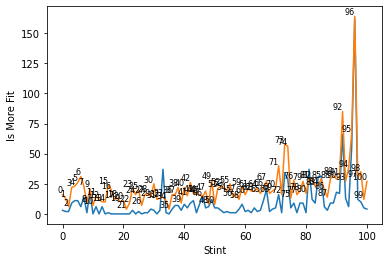

In [13]:
sns.lineplot(
    data=dfz,
    x="Stint",
    y="Is More Fit",
)
sns.lineplot(
    data=dfz,
    x="Stint",
    y="Is Less Fit",
)
# Add small text labels for each point
for x, y in zip(dfz["Stint"], dfz["Is Less Fit"]):
    plt.text(x, y, str(x), fontsize=8, ha='right', va='bottom')

# sns.lineplot(
#     data=dfz,
#     x="Stint",
#     y="Is Neutral",
# )


<AxesSubplot:xlabel='Stint', ylabel='Is Less Fit'>

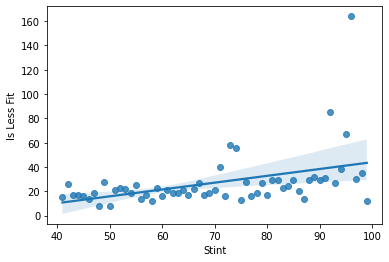

In [14]:
sns.regplot(
    data=dfz[
        (dfz["Stint"] > 40)
        & (dfz["Stint"] < 100)
    ],
    x="Stint",
    y="Is Less Fit",
    scatter=True,
)


In [15]:
ys1 = dfz.loc[
    (dfz["Stint"] > 0)
    & (dfz["Stint"] < 90),
    "Is Less Fit",
]
ys2 = dfz.loc[
    (dfz["Stint"] > 0)
    & (dfz["Stint"] < 90),
    "Stint",
]

# Parametric: Pearson correlation
pearson_corr, pearson_p = stats.pearsonr(ys1, ys2)
print(f"Pearson correlation: r={pearson_corr:.3f}, p={pearson_p:.3g}")

# Nonparametric: Spearman correlation
spearman_corr, spearman_p = stats.spearmanr(ys1, ys2)
print(f"Spearman correlation: r={spearman_corr:.3f}, p={spearman_p:.3g}")


Pearson correlation: r=0.424, p=3.5e-05
Spearman correlation: r=0.430, p=2.64e-05


<AxesSubplot:xlabel='Stint', ylabel='Is Less Fit'>

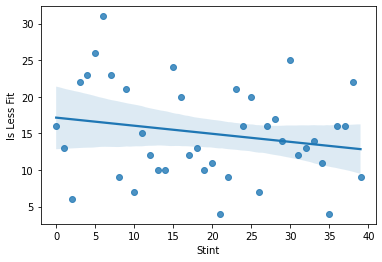

In [16]:
sns.regplot(
    data=dfz[
        (dfz["Stint"] < 40)
    ],
    x="Stint",
    y="Is Less Fit",
    scatter=True,
)


In [17]:
ys1 = dfz.loc[
    (dfz["Stint"] < 40),
    "Is Less Fit",
]
ys2 = dfz.loc[
    (dfz["Stint"] < 40),
    "Stint",
]

# Parametric: Pearson correlation
pearson_corr, pearson_p = stats.pearsonr(ys1, ys2)
print(f"Pearson correlation: r={pearson_corr:.3f}, p={pearson_p:.3g}")

# Nonparametric: Spearman correlation
spearman_corr, spearman_p = stats.spearmanr(ys1, ys2)
print(f"Spearman correlation: r={spearman_corr:.3f}, p={spearman_p:.3g}")


Pearson correlation: r=-0.200, p=0.216
Spearman correlation: r=-0.149, p=0.358


<AxesSubplot:xlabel='Stint', ylabel='Is Less Fit'>

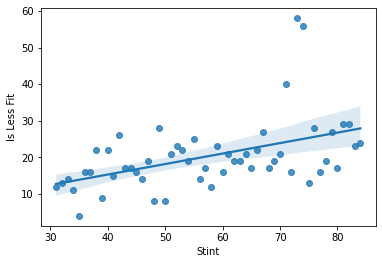

In [18]:
sns.regplot(
    data=dfz[
        (dfz["Stint"] > 30)
        & (dfz["Stint"] < 85)
    ],
    x="Stint",
    y="Is Less Fit",
    scatter=True,
)
